In [4]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from tensorflow.keras.datasets import fashion_mnist
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import MaxPooling2D, Conv2D, Flatten, Dense

In [5]:
(x_train,y_train),(x_test,y_test) = fashion_mnist.load_data()

29515/29515 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step
26421880/26421880 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step
5148/5148 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step
4422102/4422102 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step


In [6]:
# Normalize data because image pixel value range from 0 to 255
x_train = x_train/255.0
x_test = x_test/255.0

In [9]:
# CNN expects input into this format (samples, height, width, channels)
# out current data has 60000 samples (we are writing -1 because it auto calculates the number of sample)
# each image is of 28x28
#all images are greyscale so channel = 1 if image is RGB then channel is 3
x_train = x_train.reshape(-1,28,28,1)
x_test = x_test.reshape(-1,28,28,1)

In [12]:
model = Sequential()
# this layer detects features like edges,patterns,shapes
# 32->no. of filters,(3,3) filter size
model.add(Conv2D(32,(3,3),activation='relu',input_shape=(28,28,1)))
# reduce image size while keeping important features
# 28*28 = 14*14
model.add(MaxPooling2D((2,2)))
# 2d matrix -> single row
model.add(Flatten())
# hidden dense layer (model starts learning from here)
model.add(Dense(64,activation='relu'))
# softmax calculates probability
model.add(Dense(10,activation='softmax'))


/usr/local/lib/python3.12/dist-packages/keras/src/layers/convolutional/base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


In [13]:
model.compile(optimizer='adam',loss='sparse_categorical_crossentropy',metrics=['accuracy'])

In [15]:
model.fit(x_train,y_train,epochs=1)

1875/1875 ━━━━━━━━━━━━━━━━━━━━ 31s 17ms/step - accuracy: 0.8785 - loss: 0.3419


In [16]:
loss,accuracy = model.evaluate(x_test,y_test)
print(accuracy)

313/313 ━━━━━━━━━━━━━━━━━━━━ 3s 8ms/step - accuracy: 0.8825 - loss: 0.3155
0.8824999928474426


In [17]:
pred=model.predict(x_test)

313/313 ━━━━━━━━━━━━━━━━━━━━ 3s 8ms/step


In [19]:
class_name = [
    "T-shirt",
    "Trouser",
    "Pullover",
    "Dress",
    "Coat",
    "Sandel",
    "Shirt",
    "Sneaker",
    "Bag",
    "Ankle boot"
]

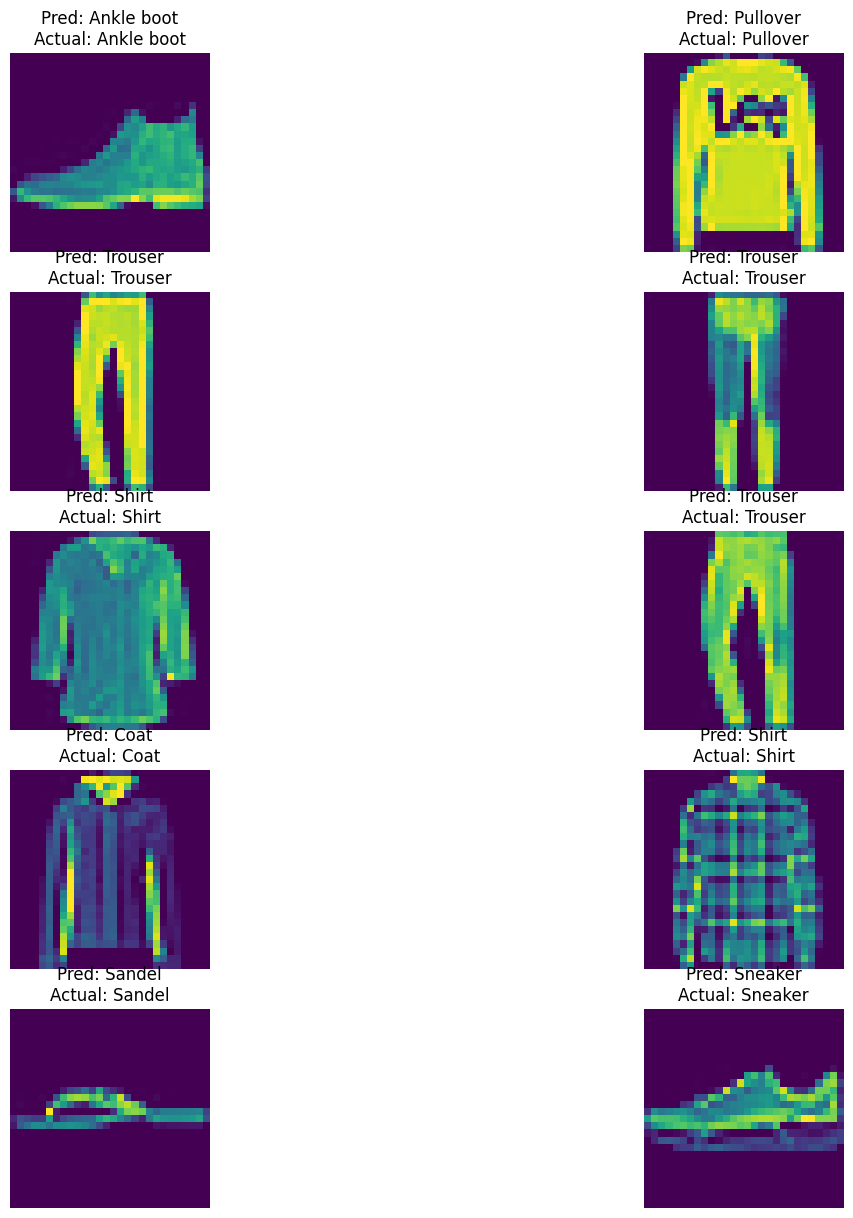

In [21]:
plt.figure(figsize=(15,15))
for i in range(10):
  plt.subplot(5,2,i+1)
  plt.imshow(x_test[i].reshape(28,28))
  plt.title("Pred: "+class_name[np.argmax(pred[i])] + "\nActual: "+class_name[y_test[i]])
  plt.axis("off")
plt.show()